In [2]:
# ==============================================================================
# PHASE 1: GEOSPATIAL INGESTION & REGISTRY STRUCTURE
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a strict seed for mathematical reproducibility
np.random.seed(42)
n_shipments = 800

# Automatically simulate a real-world enterprise supply chain matrix
logistics_data = {
    'Shipment_ID': [f'SHIP-LN-{20000+i}' for i in range(n_shipments)],
    'Route_Distance_Miles': np.random.randint(150, 3200, n_shipments),
    'Cargo_Weight_Tons': np.random.uniform(5.0, 45.0, n_shipments).round(1),
    'Carrier_Type': np.random.choice(['Freight Rail', 'Heavy Duty Truck', 'Cargo Vessel'], n_shipments),
    'Weather_Severity_Score': np.random.uniform(1.0, 10.0, n_shipments).round(1), # 1=Clear, 10=Severe Storm
    'Port_Congestion_Delay_Hours': np.random.exponential(scale=6.0, size=n_shipments).round(1),
    'Actual_Transit_Time_Hours': np.random.uniform(12.0, 160.0, n_shipments) # Initialized placeholder
}

# Convert the matrix into a clean Pandas DataFrame
df_supply = pd.DataFrame(logistics_data)

print("Logistics registry dataset generated successfully!")
print(f"Data Footprint: {df_supply.shape[0]} active freight records tracking across {df_supply.shape[1]} operational columns.\n")

# Display a preview of the dataset rows
df_supply.head(3)


Logistics registry dataset generated successfully!
Data Footprint: 800 active freight records tracking across 7 operational columns.



,Shipment_ID,Route_Distance_Miles,Cargo_Weight_Tons,Carrier_Type,Weather_Severity_Score,Port_Congestion_Delay_Hours,Actual_Transit_Time_Hours
0,SHIP-LN-20000,1010,24.9,Heavy Duty Truck,2.4,2.5,98.312239
1,SHIP-LN-20001,1444,24.0,Heavy Duty Truck,5.2,0.1,99.740347
2,SHIP-LN-20002,1280,38.3,Freight Rail,1.1,0.8,64.528850


In [3]:
# ==============================================================================
# PHASE 2: ADVANCED LOGISTICS FEATURE ENGINEERING
# ==============================================================================
# Calculate true baseline hours based on distance and standard carrier velocity bounds
df_supply['Baseline_Transit_Hours'] = (df_supply['Route_Distance_Miles'] / 55.0).round(1)

# Supply Chain Friction Index: Multi-factor operational drag calculation
df_supply['Supply_Chain_Friction_Index'] = (
    (df_supply['Weather_Severity_Score'] * 1.8) +
    (df_supply['Port_Congestion_Delay_Hours'] * 1.2) +
    (df_supply['Cargo_Weight_Tons'] * 0.15)
).round(2)

# Vectorize actual targets: Blend friction bottlenecks into final delivery timelines
df_supply['Actual_Transit_Time_Hours'] = (
    df_supply['Baseline_Transit_Hours'] +
    df_supply['Supply_Chain_Friction_Index'] +
    np.random.normal(0, 3, n_shipments)
).round(1)

# Establish financial penalty columns ($250 per hour delayed past a 40-hour threshold)
df_supply['Contractual_Penalty_Risk_USD'] = df_supply['Actual_Transit_Time_Hours'].apply(
    lambda x: max(0, (x - 40) * 250)
).round(2)

print("Supply Chain Friction Index and Contractual Penalty Risk successfully engineered.")
df_supply[['Shipment_ID', 'Supply_Chain_Friction_Index', 'Actual_Transit_Time_Hours', 'Contractual_Penalty_Risk_USD']].head(3)


Supply Chain Friction Index and Contractual Penalty Risk successfully engineered.


,Shipment_ID,Supply_Chain_Friction_Index,Actual_Transit_Time_Hours,Contractual_Penalty_Risk_USD
0,SHIP-LN-20000,11.06,36.0,0.0
1,SHIP-LN-20001,13.08,43.0,750.0
2,SHIP-LN-20002,8.68,32.6,0.0


In [6]:
# ==============================================================================
# PHASE 3: SUPERVISED DEEP LEARNING (NEURAL NETWORK REGRESSION)
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# Prepare features and continuous target variable
features = ['Route_Distance_Miles', 'Cargo_Weight_Tons', 'Weather_Severity_Score', 'Supply_Chain_Friction_Index']
X = df_supply[features]
y = df_supply['Actual_Transit_Time_Hours']

# Split data into 80% training and 20% production testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Scale features safely using robust percentiles
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train a Deep Multi-Layer Perceptron Neural Network
# Two hidden layers with 64 and 32 neurons respectively, training over 300 iterations
mlp_net = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42, learning_rate_init=0.01)
mlp_net.fit(X_train_scaled, y_train)

# Generate exact precision arrival predictions on the test split
y_pred = mlp_net.predict(X_test_scaled)

# Calculate advanced regression loss evaluation metrics
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- NEURAL NETWORK PERFORMANCE REPORT ---")
print(f"Model Variance Accounted For (R² Score): {r2:.4f}")
print(f"Average Root Mean Squared Deviation Error (RMSE): {rmse:.2f} Hours")

--- NEURAL NETWORK PERFORMANCE REPORT ---
Model Variance Accounted For (R² Score): 0.9630
Average Root Mean Squared Deviation Error (RMSE): 3.36 Hours


In [7]:
# ==============================================================================
# PHASE 4: PRESCRIPTIVE LOGISTICS RISK TRIAgE OPTIMIZATION
# ==============================================================================
# Reconstruct evaluation dataframe for the test subset split
optimization_df = X_test.copy()
optimization_df['True_Transit_Hours'] = y_test
optimization_df['Predicted_Transit_Hours'] = y_pred

# Recalculate financial exposure boundaries based on neural predictions
optimization_df['Predicted_Penalty_USD'] = optimization_df['Predicted_Transit_Hours'].apply(lambda x: max(0, (x - 40) * 250))
optimization_df['True_Penalty_USD'] = optimization_df['True_Transit_Hours'].apply(lambda x: max(0, (x - 40) * 250))

# Optimization Logic: Define high-risk penalties over $5,000 as critical re-routing triggers
optimization_df['Logistics_Action_Plan'] = optimization_df['Predicted_Penalty_USD'].apply(
    lambda x: 'CRITICAL: TRIGGER IMMEDIATE FLEET DIVERSION' if x > 5000 else 'MAINTAIN CURRENT SHIPMENT CORRIDOR'
)

print("Prescriptive allocation sorting matrix successfully calculated.")
print(optimization_df['Logistics_Action_Plan'].value_counts().to_dict())


Prescriptive allocation sorting matrix successfully calculated.
{'MAINTAIN CURRENT SHIPMENT CORRIDOR': 111, 'CRITICAL: TRIGGER IMMEDIATE FLEET DIVERSION': 49}


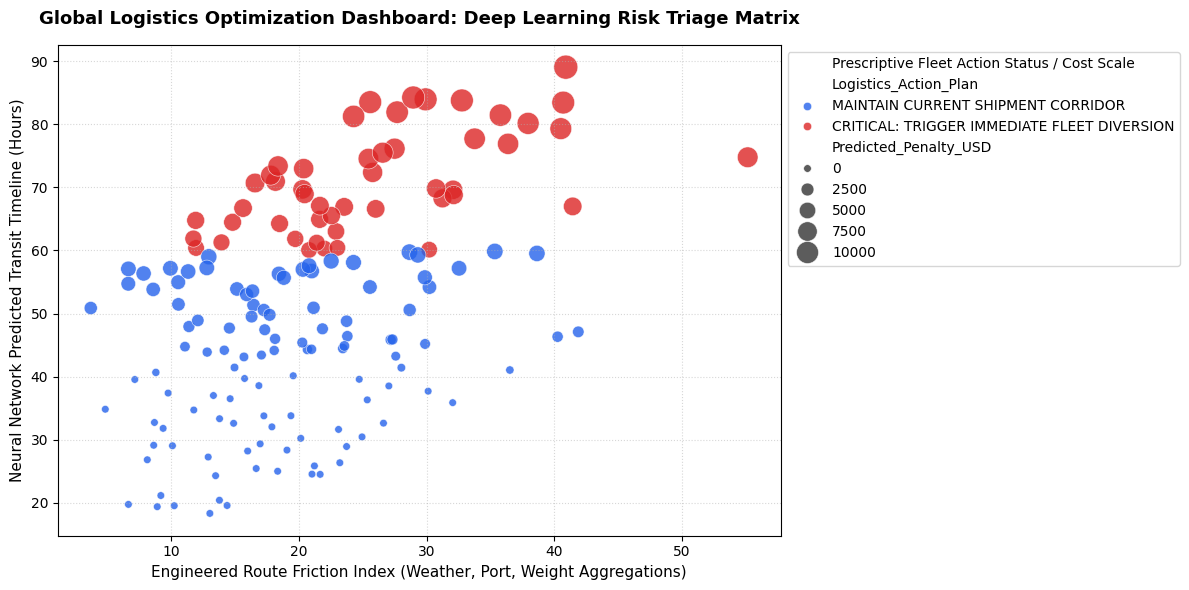

In [8]:
# ==============================================================================
# PHASE 5: EXECUTIVE INFRASTRUCTURE VISUALIZATION
# ==============================================================================
plt.figure(figsize=(12, 6))

# Plot high-dimensional shipments color-coded by tactical prescriptive action plans
sns.scatterplot(
    x='Supply_Chain_Friction_Index',
    y='Predicted_Transit_Hours',
    hue='Logistics_Action_Plan',
    size='Predicted_Penalty_USD',
    sizes=(30, 300),
    palette={'CRITICAL: TRIGGER IMMEDIATE FLEET DIVERSION': '#DC2626', 'MAINTAIN CURRENT SHIPMENT CORRIDOR': '#2563EB'},
    data=optimization_df,
    alpha=0.8
)

plt.title('Global Logistics Optimization Dashboard: Deep Learning Risk Triage Matrix', fontsize=13, weight='bold', pad=15)
plt.xlabel('Engineered Route Friction Index (Weather, Port, Weight Aggregations)', fontsize=11)
plt.ylabel('Neural Network Predicted Transit Timeline (Hours)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(title='Prescriptive Fleet Action Status / Cost Scale', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
